In [1]:
!pip install wordcloud

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer

from collections import Counter

sns.set_style("whitegrid")

In [7]:
plt.rcParams['figure.figsize'] = (12,6)
DATA_PATH = "municipal_training_set_1100.csv"


In [9]:
df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)


Dataset Shape: (1100, 26)


In [11]:
df.head()

df.info()

df.isnull().sum()

df.describe(include='all')
issue_counts = df['issue_type'].value_counts()

print(issue_counts)

plt.figure(figsize=(12,6))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   report_id                1100 non-null   object 
 1   resident_id              1100 non-null   object 
 2   resident_name            1037 non-null   object 
 3   resident_email           1037 non-null   object 
 4   resident_phone           1022 non-null   object 
 5   issue_type               1100 non-null   object 
 6   issue_description        1100 non-null   object 
 7   issue_status             1100 non-null   object 
 8   report_datetime          1100 non-null   object 
 9   location_street_address  1100 non-null   object 
 10  location_city            1100 non-null   object 
 11  location_state           1100 non-null   object 
 12  location_postal_code     1100 non-null   int64  
 13  location_country         1100 non-null   object 
 14  latitude                

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

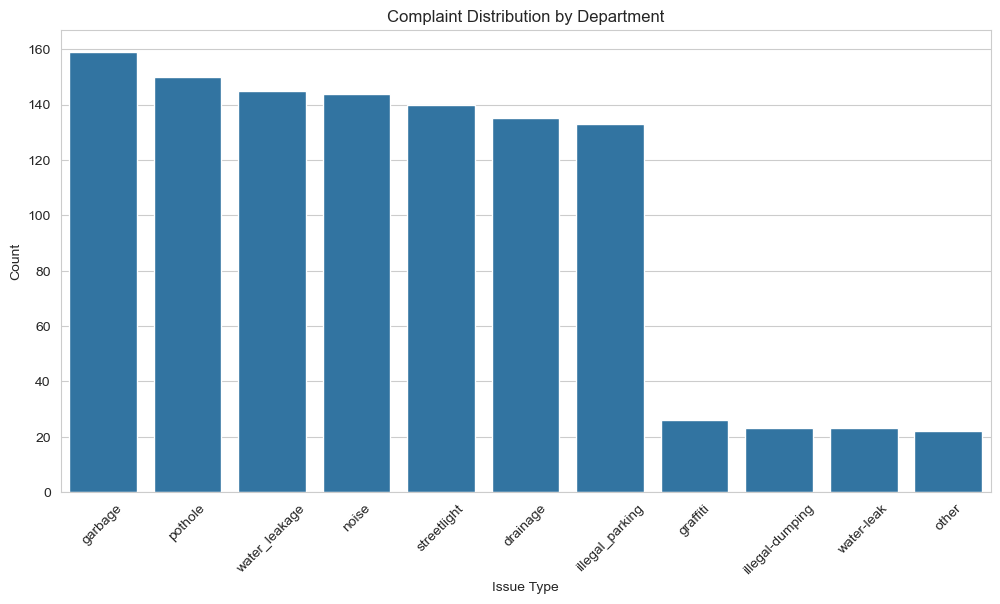

In [13]:
sns.countplot(
    data=df,
    x='issue_type',
    order=df['issue_type'].value_counts().index
)

plt.title("Complaint Distribution by Department")
plt.xlabel("Issue Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [15]:
issue_percentage = (
    df['issue_type']
    .value_counts(normalize=True) * 100
)

issue_percentage

all_text = " ".join(df['issue_description'].astype(str))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(all_text)


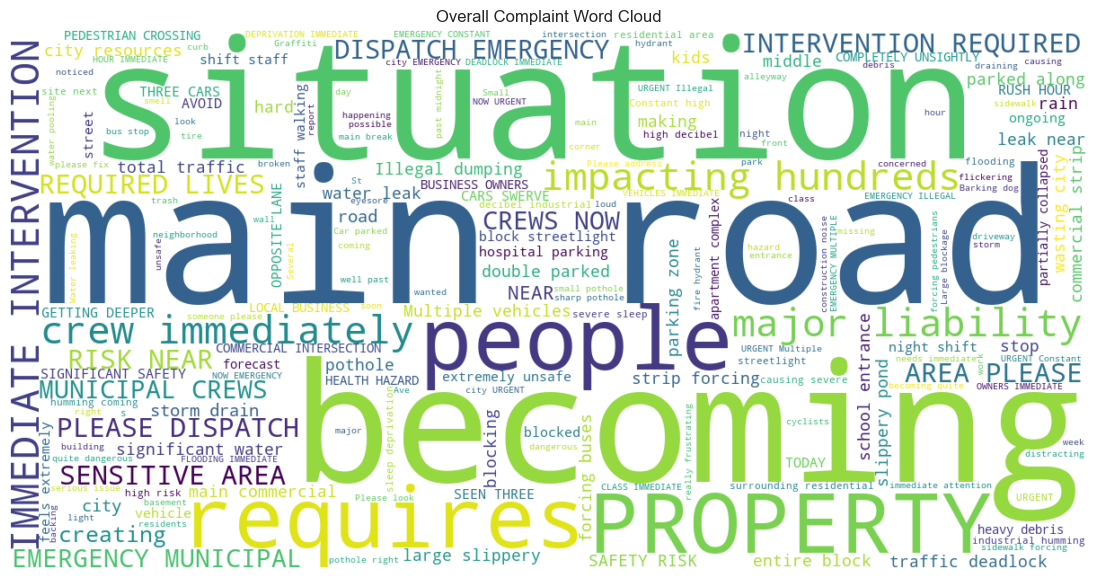

In [16]:
plt.figure(figsize=(15,7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Overall Complaint Word Cloud")

plt.show()

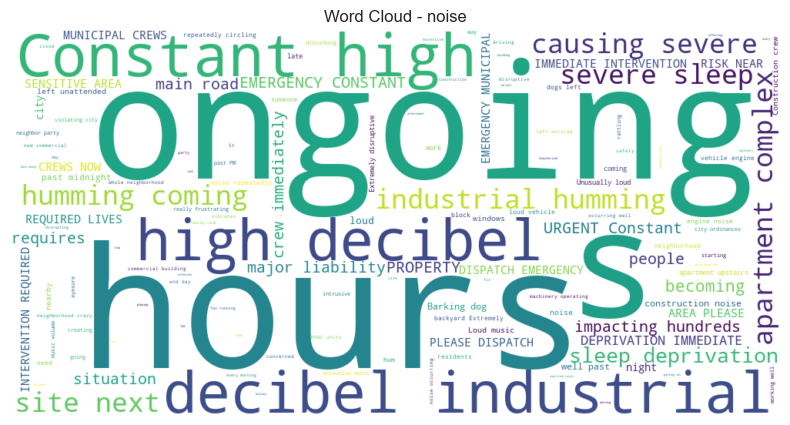

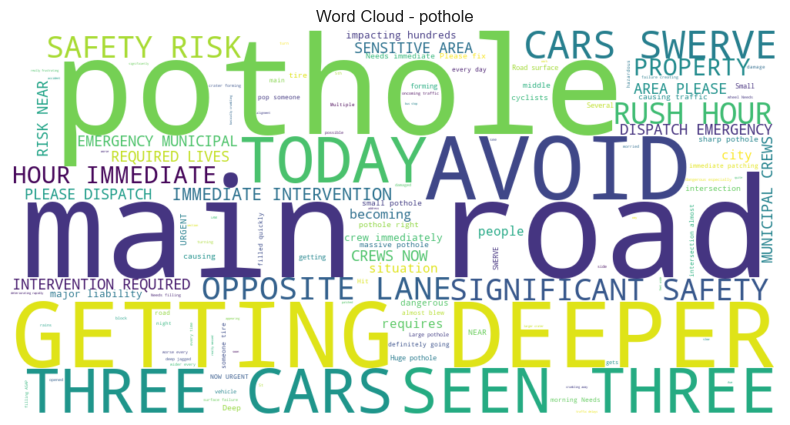

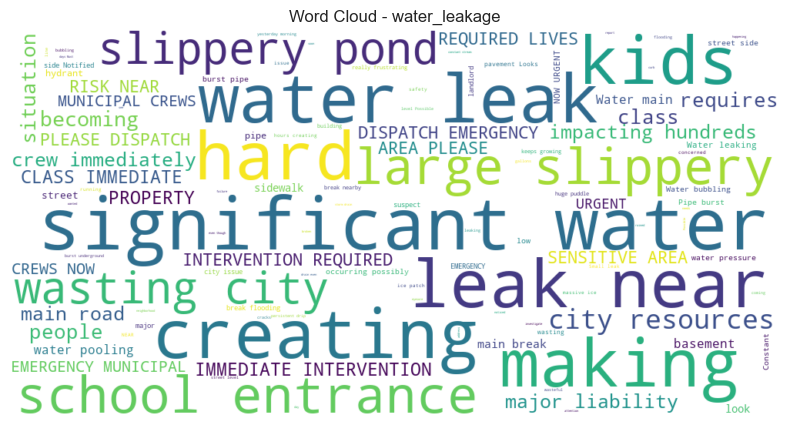

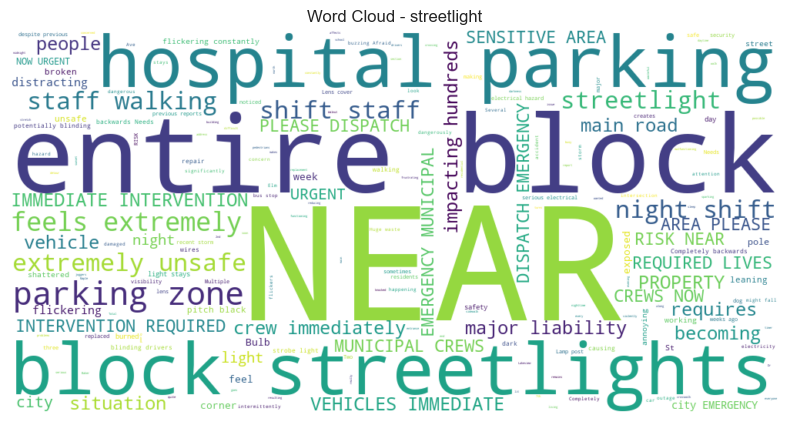

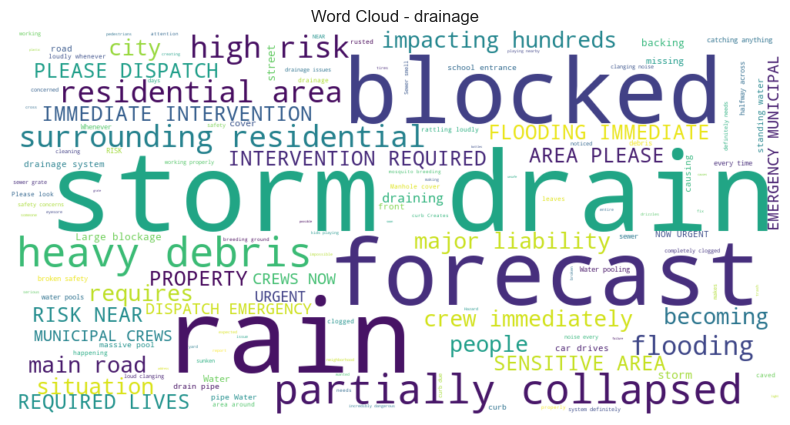

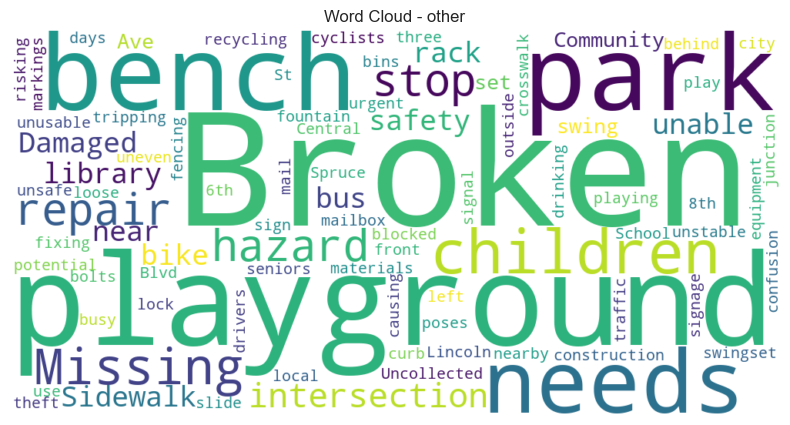

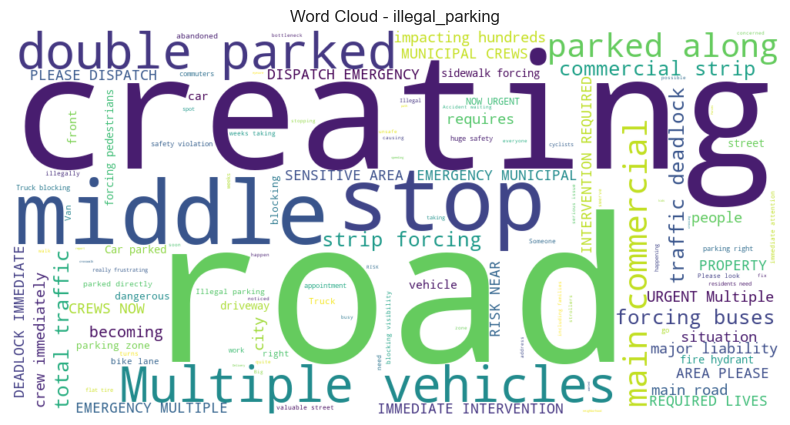

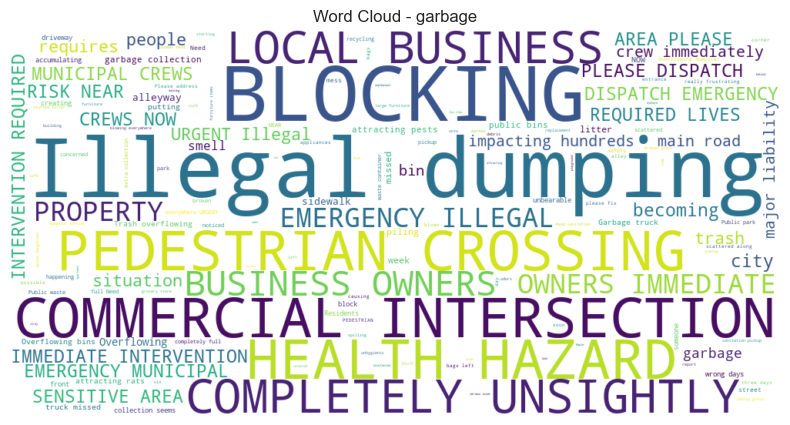

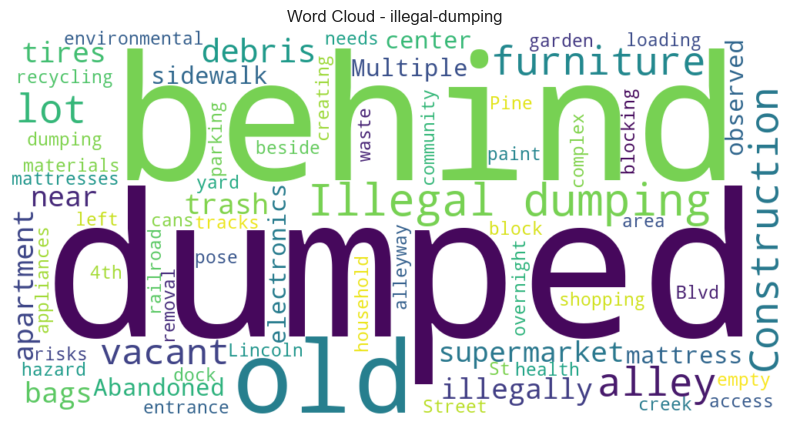

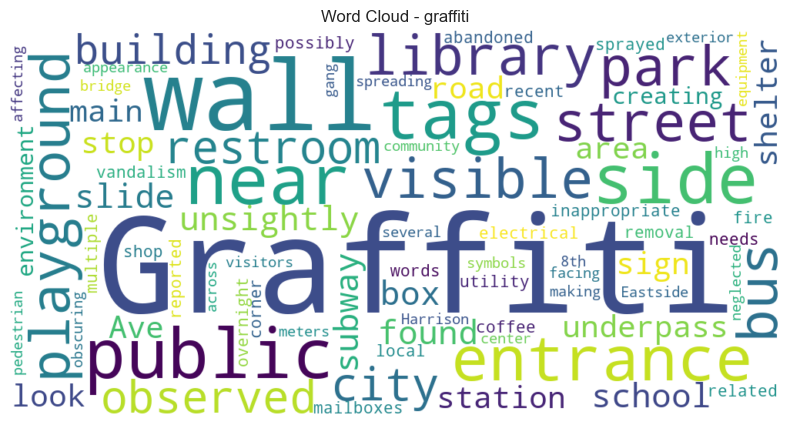

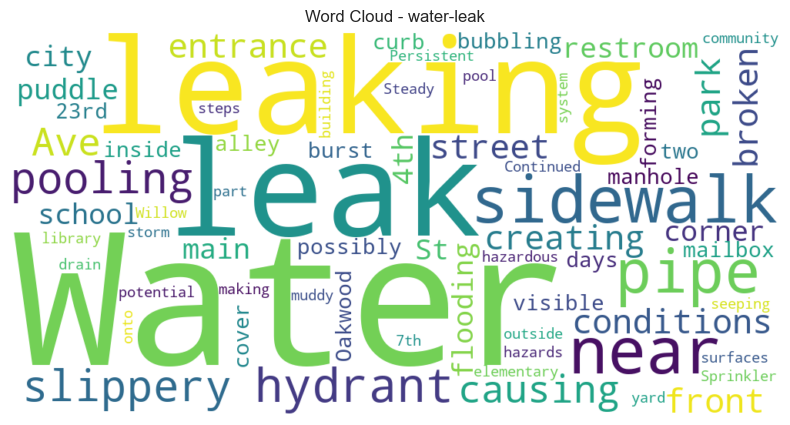

In [19]:
departments = df['issue_type'].unique()

for dept in departments:

    dept_text = " ".join(
        df[df['issue_type'] == dept]['issue_description'].astype(str)
    )

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color='white'
    ).generate(dept_text)
    plt.figure(figsize=(12,5))

    plt.imshow(wordcloud, interpolation='bilinear')

    plt.axis('off')

    plt.title(f"Word Cloud - {dept}")

    plt.show()

    bigram_vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words='english'
)

bigram_matrix = bigram_vectorizer.fit_transform(
    df['issue_description'].astype(str)
)

bigram_counts = bigram_matrix.sum(axis=0)

bigram_freq = [
    (word, bigram_counts[0, idx])
    for word, idx in bigram_vectorizer.vocabulary_.items()
]


In [1]:
bigram_freq = sorted(
    bigram_freq,
    key=lambda x: x[1],
    reverse=True
)

bigram_df = pd.DataFrame(
    bigram_freq[:20],
    columns=['Bigram', 'Frequency']
)

bigram_df.head()

plt.figure(figsize=(12,7))

sns.barplot(
    data=bigram_df,
    x='Frequency',
    y='Bigram'
)

plt.title("Top 20 Most Common Bigrams")

plt.xlabel("Frequency")

plt.ylabel("Bigram")

plt.show()

trigram_vectorizer = CountVectorizer(
    ngram_range=(3,3),
    stop_words='english'
)

trigram_matrix = trigram_vectorizer.fit_transform(
    df['issue_description'].astype(str)
)

trigram_counts = trigram_matrix.sum(axis=0)

trigram_freq = [
    (word, trigram_counts[0, idx])
    for word, idx in trigram_vectorizer.vocabulary_.items()
]

trigram_freq = sorted(
    trigram_freq,
    key=lambda x: x[1],
    reverse=True
)

trigram_df = pd.DataFrame(
    trigram_freq[:20],
    columns=['Trigram', 'Frequency']
)

trigram_df.head()

plt.figure(figsize=(12,7))

sns.barplot(
    data=trigram_df,
    x='Frequency',
    y='Trigram'
)

plt.title("Top 20 Most Common Trigrams")

plt.xlabel("Frequency")

plt.ylabel("Trigram")

plt.show()
df['text_length'] = df['issue_description'].astype(str).apply(len)

df['text_length'].describe()

plt.figure(figsize=(12,6))

sns.histplot(
    df['text_length'],
    bins=30D
)

plt.title("Complaint Text Length Distribution")

plt.xlabel("Text Length")

plt.ylabel("Frequency")

plt.show()

SyntaxError: invalid decimal literal (537258971.py, line 82)